**1. Upload dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


**2. Extract ZipFile**

In [2]:
import zipfile

with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as zip_ref:
    zip_ref.extractall("dataset")

**3. Import Libraries**

In [3]:
!pip install opencv-python-headless numpy pillow pandas

**4. Dataset Preprocessing and Model Training**

In [4]:
import cv2
import os
import numpy as np

data_path = "dataset/Dataset"

faces = []
labels = []
names = []
label_id = 0

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

for person in os.listdir(data_path):
    person_path = os.path.join(data_path, person)

    if not os.path.isdir(person_path):
        continue

    names.append(person)

    for img_name in os.listdir(person_path):
        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        faces_detected = face_detector.detectMultiScale(
            gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(60,60)
        )

        # ✅ DEBUG
        print("Detected faces:", len(faces_detected))

        for (x,y,w,h) in faces_detected:
            face = gray[y:y+h, x:x+w]
            face = cv2.resize(face, (200,200))

            faces.append(face)
            labels.append(label_id)

    label_id += 1

# ✅ DEBUG
print("Total faces collected:", len(faces))

# 🚨 SAFETY CHECK
if len(faces) == 0:
    print("❌ No faces detected. Fix dataset!")
    exit()

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(faces, np.array(labels))

print("✅ Training completed")

Detected faces: 1
Detected faces: 1
Detected faces: 2
Detected faces: 0
Detected faces: 1
Detected faces: 1
Detected faces: 3
Detected faces: 1
Detected faces: 1
Detected faces: 1
Detected faces: 1
Detected faces: 3
Detected faces: 1
Detected faces: 0
Detected faces: 1
Detected faces: 1
Detected faces: 1
Detected faces: 2
Detected faces: 0
Detected faces: 0
Detected faces: 1
Detected faces: 1
Detected faces: 2
Total faces collected: 26
✅ Training completed


**5. Upload Test Image**

In [7]:
uploaded = files.upload()

Saving testimage.jpeg to testimage (1).jpeg


**6. Face Recognition and Attendance Marking**

Faces detected: 1
Confidence: 22.109939094919348


(np.float64(-0.5), np.float64(1079.5), np.float64(1359.5), np.float64(-0.5))

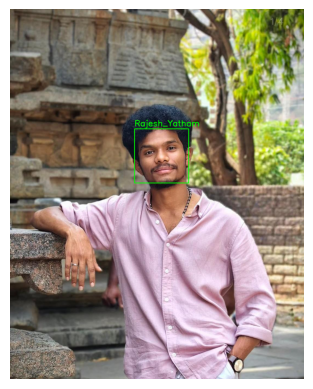

In [8]:
import csv
from datetime import datetime
import matplotlib.pyplot as plt

def mark_attendance(name):
    filename = "my_attendancee.csv"

    if not os.path.exists(filename):
        with open(filename, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Name","Date","Time"])

    today = datetime.now().strftime("%d-%m-%Y")
    time_now = datetime.now().strftime("%H:%M:%S")

    with open(filename, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([name, today, time_now])

# Read image
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=5,
    minSize=(60,60)
)

print("Faces detected:", len(faces))

if len(faces) > 0:
    # ✅ Take biggest face
    faces = sorted(faces, key=lambda x: x[2]*x[3], reverse=True)
    (x,y,w,h) = faces[0]

    face = gray[y:y+h, x:x+w]
    face = cv2.resize(face, (200,200))

    label, confidence = recognizer.predict(face)

    print("Confidence:", confidence)

    if confidence < 60:
        name = names[label]
        mark_attendance(name)
        color = (0,255,0)
    else:
        name = "Unknown"
        color = (0,0,255)

    cv2.putText(img, name, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    cv2.rectangle(img, (x,y), (x+w,y+h), color, 2)

# Show result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

**7. View Attendance**

In [9]:
import pandas as pd
df = pd.read_csv("my_attendancee.csv")
df

,Name,Date,Time
0,Rajesh_Yatham,02-05-2026,14:03:32
